In [1]:
import fenics
import mshr
import dolfin
import matplotlib.pyplot as plt
import numpy as np
import copy 
import time
import pandas as pd

Consider a stationary incompressible sourceless Stokes flow over a step with a constant viscosity $\mu = 0.001$. The inflow profile on the left side is $$u(x,y) = \begin{pmatrix}-15\frac{4(y-0.2)(y-0.4)}{0.2^2}\\0\end{pmatrix}$$ Assume zero velocity on the top and bottom sides. The outflow boundary condition is $p = 0$ (pressure-driven flow).

Stokes equations (incompressible, no forcing term): 
$$\mu\Delta u -\nabla p = 0$$
$$\nabla\cdot u = 0$$


## Weak formulation

$$-\int v\cdot\mu\Delta u +\int v\cdot\nabla p = 0$$
$$-\int q \nabla\cdot u = 0$$

The first term:
$$\int \mu\nabla v:\nabla u -\int_\Gamma n\cdot(\mu v\cdot\nabla u - pv) -\int p\nabla\cdot v = 0$$
$$\int \mu\nabla v:\nabla u  -\int p\nabla\cdot v = 0$$
The second term:
$$-\int q\nabla\cdot u = 0$$
And the overall formulation in product spaces is
$$\int \mu\nabla v:\nabla u - \int q\nabla\cdot u -\int p\nabla\cdot v = 0$$


In [3]:
#set up the geometry
rec1 = mshr.Rectangle(dolfin.Point(0,0.4), dolfin.Point(2., 0.))
rec2 = mshr.Rectangle(dolfin.Point(0,0.2), dolfin.Point(0.75,0))
geom = rec1 - rec2

Number of vertices in mesh of size 50: 1293
Number of vertices in mesh of size 75: 2850
Number of vertices in mesh of size 100: 5026


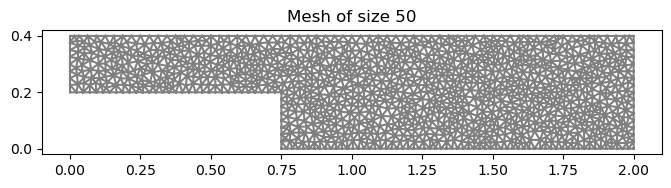

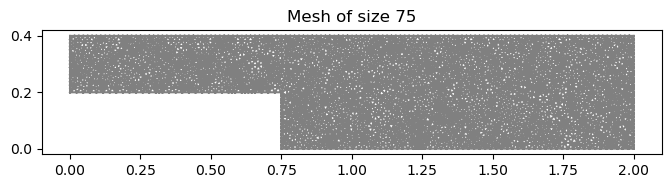

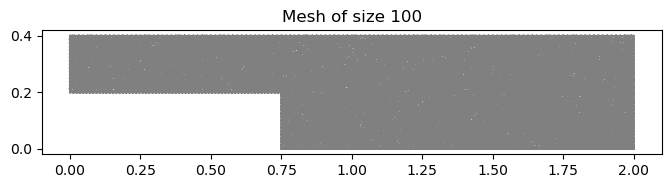

In [4]:
meshsizes = [50,75,100]
for m in meshsizes:
    plt.figure(figsize = (8,8), dpi = 100)
    plt.title(f'Mesh of size {m}')
    mesh = mshr.generate_mesh(geom, m)
    fenics.plot(mesh)
    print(f"Number of vertices in mesh of size {m}:", mesh.num_vertices())

In [9]:
velocities = {}
pressures = {}
# times = []
# iterations = []
for meshsize in meshsizes:
    mesh = mshr.generate_mesh(geom, meshsize)
    #set up the subdomains
    class Inflow(dolfin.SubDomain):
        def inside(self, x, on_boundary):
            return (on_boundary)&dolfin.near(x[0], 0, 1e-16)
    class Outflow(dolfin.SubDomain):
        def inside(self, x, on_boundary):
            return (on_boundary)&dolfin.near(x[0], 2., 1e-16)
    class Wall(dolfin.SubDomain):
        def inside(self, x, on_boundary):
            # return (on_boundary)&~(dolfin.near(x[0], 2.2, 1e-16)|dolfin.near(x[0], 0, 1e-16))
            return (on_boundary) and ((dolfin.near(x[1], 0.2, 1e-16) and (x[0] <= 0.75)) 
                                      or (dolfin.near(x[1], 0, 1e-16) and (x[0] >= 0.75)) 
                                      or (dolfin.near(x[1], 0.4, 1e-16)) 
                                      or (dolfin.near(x[0], 0.75, 1e-16) and x[1] <= 0.2 ))
    P2P1 = dolfin.MixedElement([dolfin.VectorElement('Lagrange', 'triangle', 2), dolfin.FiniteElement('Lagrange', 'triangle', 1)])
    W = dolfin.FunctionSpace(mesh, P2P1)
    inflow = Inflow()
    outflow = Outflow()
    walls = Wall()
    inflowProfile = dolfin.Expression(('-15*4*(x[1] - 0.2)*(x[1] - 0.4)/pow(0.2,2)','0'), degree = 2)
    velocity_bcs = [fenics.DirichletBC(W.sub(0), inflowProfile, inflow),
                fenics.DirichletBC(W.sub(0), dolfin.Constant(('0', '0')), walls),
                ]
    pressure_bcs = [fenics.DirichletBC(W.sub(1), dolfin.Constant(0), outflow)]
    (u, p) = dolfin.TrialFunctions(W)
    (v, q) = dolfin.TestFunctions(W)
    w = dolfin.Function(W)
    mu = 1e-3
    f = dolfin.Constant(('0', '0'))
    RHS = dolfin.dot(f, v)*dolfin.dx
    LHS = mu*dolfin.inner(dolfin.grad(u), dolfin.grad(v))*dolfin.dx+dolfin.div(u)*q*dolfin.dx+dolfin.div(v)*p*dolfin.dx
    pcLHS = mu*dolfin.inner(dolfin.grad(u), dolfin.grad(v))*dolfin.dx+p*q*dolfin.dx
    P, b_ = dolfin.assemble_system(pcLHS, RHS, velocity_bcs+pressure_bcs)
    A, b = dolfin.assemble_system(LHS, RHS, velocity_bcs+pressure_bcs)
    solver = dolfin.KrylovSolver('minres', 'hypre_amg')
    solver.set_operators(A, P)
    w = dolfin.Function(W)
    t_ = time.perf_counter()
    its = solver.solve(w.vector(), b)
    t_ = time.perf_counter() - t_
    times.append(t_)
    iterations.append(its)
    (u_, p_) = w.split(True)
    velocities[meshsize] = copy.deepcopy(u_.vector().get_local())
    pressures[meshsize] = copy.deepcopy(p_.vector().get_local())

In [8]:
times = []
iterations = []
for meshsize in meshsizes:
    time_ = []
    iteration = []
    for i in range(20):
        mesh = mshr.generate_mesh(geom, meshsize)
        #set up the subdomains
        class Inflow(dolfin.SubDomain):
            def inside(self, x, on_boundary):
                return (on_boundary)&dolfin.near(x[0], 0, 1e-16)
        class Outflow(dolfin.SubDomain):
            def inside(self, x, on_boundary):
                return (on_boundary)&dolfin.near(x[0], 2., 1e-16)
        class Wall(dolfin.SubDomain):
            def inside(self, x, on_boundary):
                # return (on_boundary)&~(dolfin.near(x[0], 2.2, 1e-16)|dolfin.near(x[0], 0, 1e-16))
                return (on_boundary) and ((dolfin.near(x[1], 0.2, 1e-16) and (x[0] <= 0.75)) 
                                          or (dolfin.near(x[1], 0, 1e-16) and (x[0] >= 0.75)) 
                                          or (dolfin.near(x[1], 0.4, 1e-16)) 
                                          or (dolfin.near(x[0], 0.75, 1e-16) and x[1] <= 0.2 ))
        P2P1 = dolfin.MixedElement([dolfin.VectorElement('Lagrange', 'triangle', 2), dolfin.FiniteElement('Lagrange', 'triangle', 1)])
        W = dolfin.FunctionSpace(mesh, P2P1)
        inflow = Inflow()
        outflow = Outflow()
        walls = Wall()
        inflowProfile = dolfin.Expression(('-15*4*(x[1] - 0.2)*(x[1] - 0.4)/pow(0.2,2)','0'), degree = 2)
        velocity_bcs = [fenics.DirichletBC(W.sub(0), inflowProfile, inflow),
                    fenics.DirichletBC(W.sub(0), dolfin.Constant(('0', '0')), walls),
                    ]
        pressure_bcs = [fenics.DirichletBC(W.sub(1), dolfin.Constant(0), outflow)] #fix gauge
        (u, p) = dolfin.TrialFunctions(W)
        (v, q) = dolfin.TestFunctions(W)
        w = dolfin.Function(W)
        mu = 1e-3
        f = dolfin.Constant(('0', '0'))
        RHS = dolfin.dot(f, v)*dolfin.dx
        LHS = mu*dolfin.inner(dolfin.grad(u), dolfin.grad(v))*dolfin.dx+dolfin.div(u)*q*dolfin.dx+dolfin.div(v)*p*dolfin.dx
        pcLHS = mu*dolfin.inner(dolfin.grad(u), dolfin.grad(v))*dolfin.dx+p*q*dolfin.dx
        P, b_ = dolfin.assemble_system(pcLHS, RHS, velocity_bcs+pressure_bcs)
        A, b = dolfin.assemble_system(LHS, RHS, velocity_bcs+pressure_bcs)
        solver = dolfin.KrylovSolver('minres', 'hypre_amg')
        solver.set_operators(A, P)
        w = dolfin.Function(W)
        t_ = time.perf_counter()
        its = solver.solve(w.vector(), b)
        t_ = time.perf_counter() - t_
        time_.append(t_)
        iteration.append(its)
    iterations.append(np.mean(iteration))
    times.append(np.mean(time_))
    

KeyboardInterrupt: 

In [97]:
table = pd.DataFrame(columns = ['mesh size', 'number of vertices', 'time', 'iterations'])
table['mesh size'] = meshsizes
table['number of vertices'] = [1293, 2850, 5026]
table['time'] = times
table['iterations'] = iterations
table

,mesh size,number of vertices,time,iterations
0,50,1293,0.801618,68.0
1,75,2850,2.269663,70.0
2,100,5026,4.578784,75.0


In [6]:
#helper to plot l1 norm instead of quiver
def quiverToL1(u):
    ux, uy = dolfin.dot(u,dolfin.Expression(('1', '0'), degree = 1)), dolfin.dot(u,dolfin.Expression(('0', '1'), degree = 1))
    return abs(ux)+abs(uy)
def npArrayToFunction(u,V):
    _ = dolfin.Function(V)
    _.vector().set_local(u)
    return _

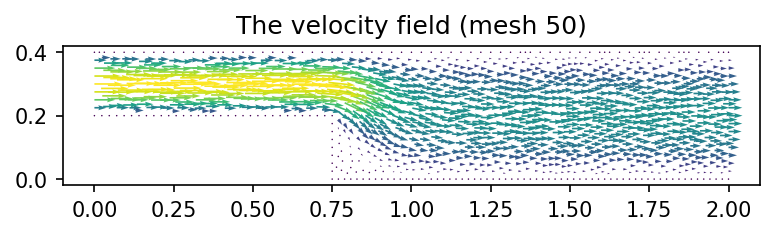

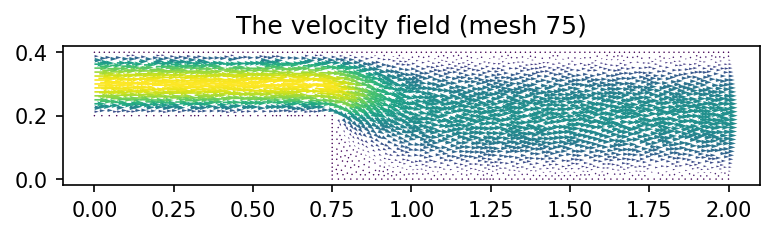

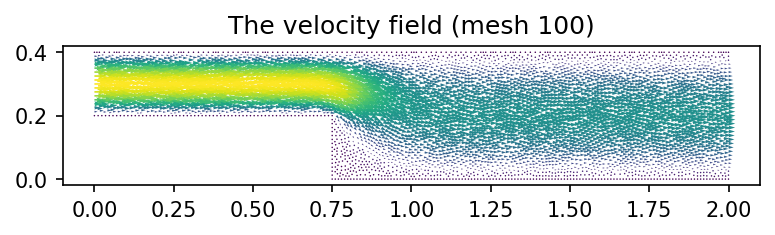

In [10]:
for m in meshsizes:
    plt.figure(figsize = (6,6), dpi = 150)
    fenics.plot(npArrayToFunction(velocities[m], dolfin.VectorFunctionSpace(
        mshr.generate_mesh(geom, m), 'P', 2)))
    plt.title(f'The velocity field (mesh {m})')

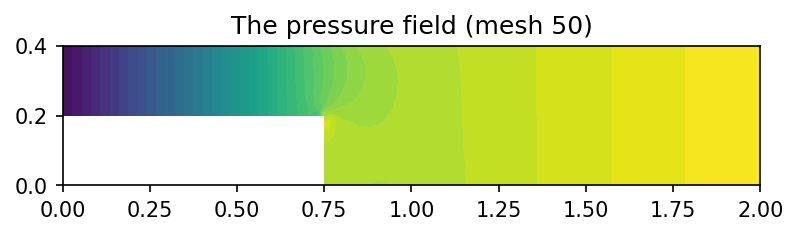

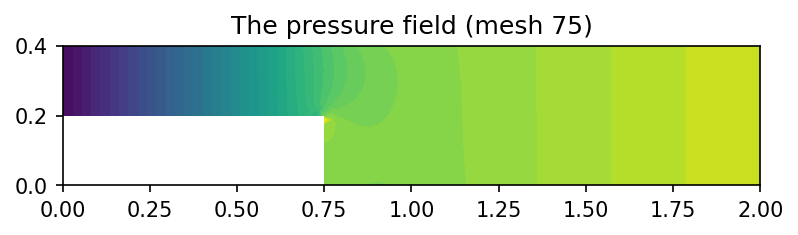

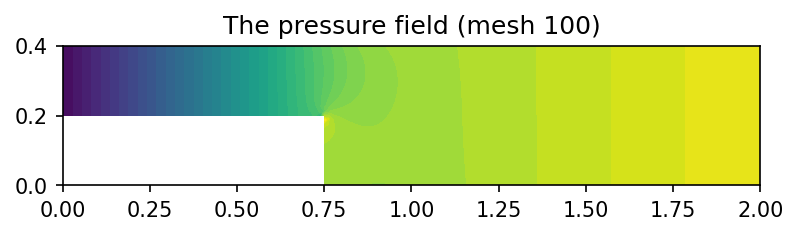

In [80]:
for m in meshsizes:
    plt.figure(figsize = (6,6), dpi = 150)
    fenics.plot(npArrayToFunction(pressures[m], dolfin.FunctionSpace(
    mshr.generate_mesh(geom, m), 'P', 1)))
    plt.title(f'The pressure field (mesh {m})')

# Discussion

The solver used in this code is a KrylovSolver with the MINRES method and hierarchical multigrid preconditioner. It sets up the operators A and P, assembles the system with the specified boundary conditions, and then solves the linear system for the unknowns using the solver. The solver takes the system matrix A and preconditioner P as input and iteratively finds the solution until convergence is reached. 

The execution time and the number of iteration increase along with the mesh size.

As the pipe cross-sectional area expands, the flow rate slows down, and the pressure, on the contrary, increases uniformly to 0.